# Predicting Online Shopping Purchase Intentions

This notebook demonstrates how to use machine learning to predict whether a user will make a purchase in an online shopping session. Models and visualizations are chosen to be clear and understandable for beginners.

---

## Introduction

We aim to predict purchase conversion on an e-commerce site. This helps a business target nudges to potential buyers, maximizing conversions and minimizing wasted efforts.

---

## Dataset Description

Data: "Online Shoppers Intention"  
- Features: page views, durations, visitor type, weekend, etc.
- Target: `Revenue` (1 = purchase, 0 = no purchase)

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("..\\data\\online_shoppers_intention.csv")
df.head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

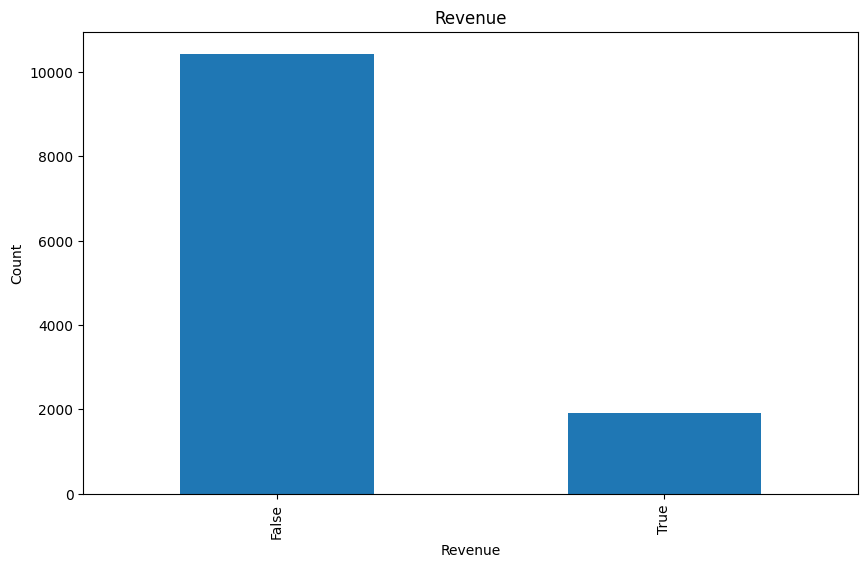

In [9]:
df["Revenue"].value_counts(normalize=True)
df["Revenue"].value_counts().plot(kind="bar", figsize=(10, 6))
plt.title("Revenue")
plt.ylabel("Count")
plt.xlabel("Revenue")
plt.show()

In [ ]:
# ==============================
# Data Preprocessing
# ==============================

# 1. Boolean columns to integer
df[["Weekend", "Revenue"]] = df[["Weekend", "Revenue"]].astype(int)

# 2. One-hot encode VisitorType
df = pd.get_dummies(df, columns=['VisitorType'], drop_first=True)

# 3. Map month names to numbers
month_map = {'Feb': 2, 'Mar': 3, 'May': 5, 'Oct': 10, 'June': 6, 'Jul': 7,
            'Aug': 8, 'Nov': 11, 'Sep': 9, 'Dec': 12}
df["Month"] = df["Month"].map(month_map)

# 4. Feature engineering: total page views and duration
df["Total_PageViews"] = df["Administrative"] + df["Informational"] + df["ProductRelated"]
df["Total_PageDuration"] = df["Administrative_Duration"] + df["Informational_Duration"] + df["ProductRelated_Duration"]

# 5. Drop original columns
df.drop(columns=["Administrative", "Informational", "ProductRelated",
                "Administrative_Duration", "Informational_Duration", "ProductRelated_Duration"], inplace=True)

# Preview processed data
df.head()


,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue,VisitorType_Other,VisitorType_Returning_Visitor,Total_PageViews,Total_PageDuration
0,0.20,0.20,0.0,0.0,2,1,1,1,1,0,0,False,True,1,0.000000
1,0.00,0.10,0.0,0.0,2,2,2,1,2,0,0,False,True,2,64.000000
2,0.20,0.20,0.0,0.0,2,4,1,9,3,0,0,False,True,1,0.000000
3,0.05,0.14,0.0,0.0,2,3,2,2,4,0,0,False,True,2,2.666667
4,0.02,0.05,0.0,0.0,2,3,3,1,4,1,0,False,True,10,627.500000


## EDA (Exploratory Data Analysis)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11828\1481631597.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Revenue', data=df, palette='pastel')


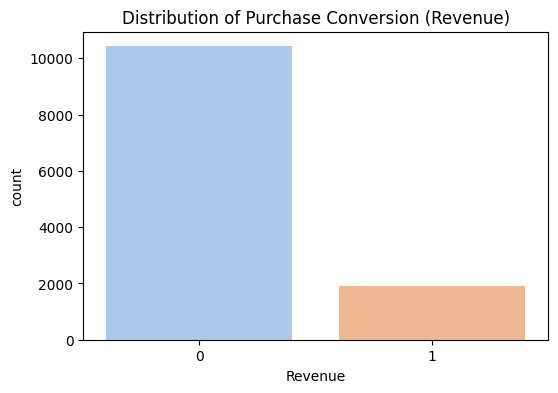

In [11]:
# Distribution of target label
plt.figure(figsize=(6,4))
sns.countplot(x='Revenue', data=df, palette='pastel')
plt.title('Distribution of Purchase Conversion (Revenue)')
plt.show()


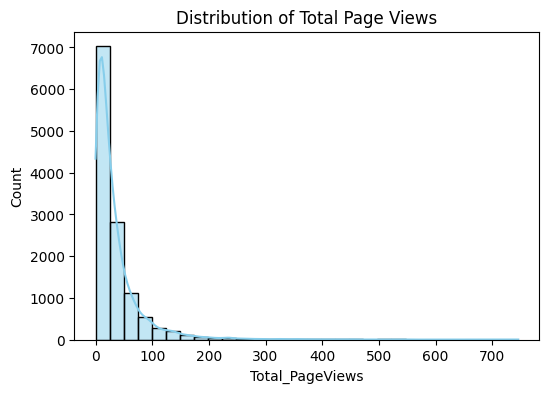

In [12]:
# Distribution of Total Page Views
plt.figure(figsize=(6,4))
sns.histplot(df['Total_PageViews'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Total Page Views')
plt.show()


## Model Comparison: Metrics & Visuals

We compare five models with precision-recall curves:
- Logistic Regression
- Support Vector Machine (SVM)
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)

We train models, scale features, and plot metric curves for comparison.


In [24]:
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

# Train-test split (stratified)
X = df.drop('Revenue', axis=1)
y = df['Revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [20]:
# Evaluate multiple models
models = {
    "Logistic Regression": LogisticRegression(solver="liblinear", random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "xgboost": XGBClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
}
metrics = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = None
    
    metrics[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc
    }

pd.DataFrame(metrics).T


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.878886,0.723022,0.351399,0.472941,0.876547
SVM,0.883752,0.684896,0.459790,0.550209,0.874467
Decision Tree,0.847526,0.506623,0.534965,0.520408,0.719833
Random Forest,0.894566,0.710648,0.536713,0.611554,0.909976
xgboost,0.892403,0.676829,0.582168,0.625940,0.912406
KNN,0.871587,0.639769,0.388112,0.483134,0.799142


ValueError: num must be an integer with 1 <= num <= 4, not 5

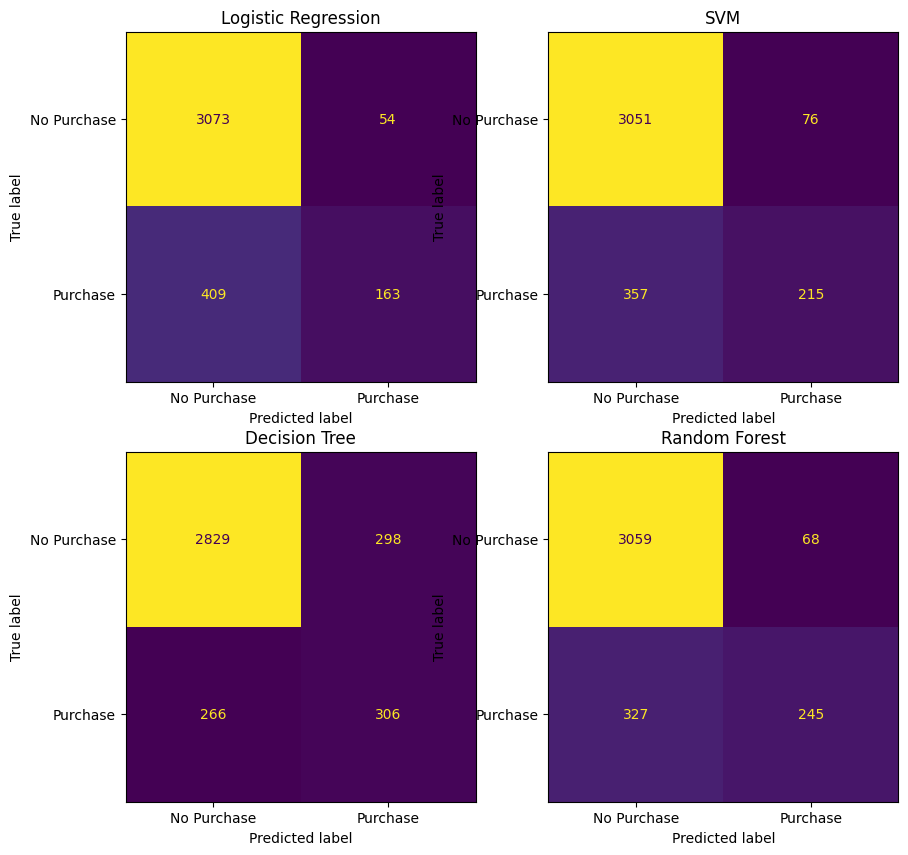

In [21]:
# List of models to evaluate (already trained or will be fit)
from sklearn.metrics import ConfusionMatrixDisplay
# Plot confusion matrices for each model    

plt.figure(figsize=(10, 10))

for idx, (name, model) in enumerate(models.items()):
    # Fit on train, predict on test
    model.fit(X_train_scaled, y_train)
    # For probability-based models, use custom threshold
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        chosen_threshold = 0.60
        y_pred = (y_prob >= chosen_threshold).astype(int)
    else:
        y_pred = model.predict(X_test_scaled)
    # Plot confusion matrix
    plt.subplot(2, 2, idx+1)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["No Purchase", "Purchase"],
        cmap='viridis',
        colorbar=False,
        ax=plt.gca()
    )
    plt.title(name)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

plt.suptitle("Model Confusion Matrices (Test Set)")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


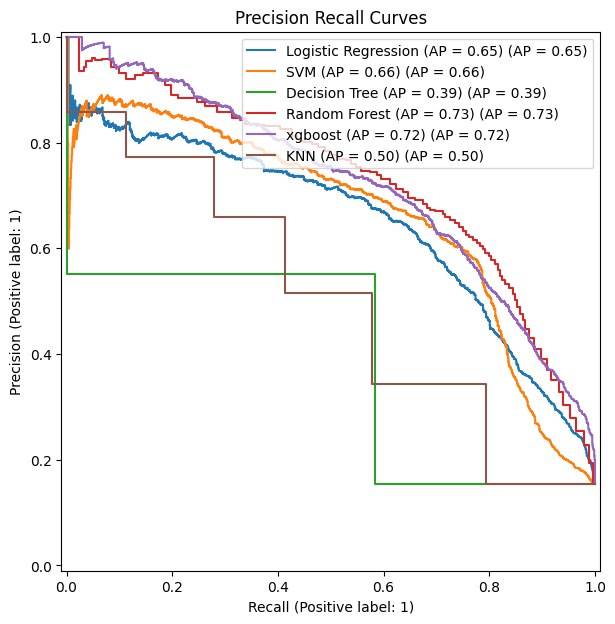

In [22]:
# Compare models with precision-recall curves

plt.figure(figsize=(10,7))
ax = plt.gca()
for name, model in models.items():
    y_proba = cross_val_predict(model, X_train_scaled, y_train, cv=5, method="predict_proba")[:, 1]
    ap = average_precision_score(y_train, y_proba)
    PrecisionRecallDisplay.from_predictions(
        y_train,
        y_proba,
        name=f"{name} (AP = {ap:.2f})",
        ax=ax
    )
plt.title("Precision Recall Curves")
plt.xlabel("Recall (Positive label: 1)")
plt.ylabel("Precision (Positive label: 1)")
plt.legend(loc="upper right")
plt.show()


## Random Forest: Threshold Tuning for Precision ≥ 0.6


In [25]:
rf_orig = RandomForestClassifier(
    n_estimators=100,  # default
    random_state=42,
    n_jobs=-1
)

rf_orig.fit(X_train, y_train)

y_prob_train = rf_orig.predict_proba(X_train)[:, 1]
chosen_threshold = 0.60
y_pred_train = (y_prob_train >= chosen_threshold).astype(int)

print("Original Random Forest (Train Set):")
print(confusion_matrix(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))
print("Precision:", precision_score(y_train, y_pred_train))
print("Recall:   ", recall_score(y_train, y_pred_train))
print("F1-Score: ", f1_score(y_train, y_pred_train))
print("Accuracy: ", accuracy_score(y_train, y_pred_train))
print("ROC-AUC:  ", roc_auc_score(y_train, y_prob_train))


Original Random Forest (Train Set):
[[7295    0]
 [  27 1309]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7295
           1       1.00      0.98      0.99      1336

    accuracy                           1.00      8631
   macro avg       1.00      0.99      0.99      8631
weighted avg       1.00      1.00      1.00      8631

Precision: 1.0
Recall:    0.9797904191616766
F1-Score:  0.9897920604914934
Accuracy:  0.9968717413972888
ROC-AUC:   1.0


In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

# Create a pipeline: SMOTE + Random Forest
pipe = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_split=8,
        min_samples_leaf=4,
        max_features='log2',
        class_weight='balanced',
        random_state=42
    ))
])

# 5-fold stratified CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Get predicted probabilities (for threshold tuning)
y_pred_prob = cross_val_predict(pipe, X_train_scaled, y_train, 
                            cv=skf, method="predict_proba", n_jobs=-1)[:, 1]

# Threshold for class prediction
chosen_threshold = 0.62  # or test a few, as you did before
y_pred = (y_pred_prob >= chosen_threshold).astype(int)

# Evaluate
print("Confusion Matrix with SMOTE and threshold {:.2f}:".format(chosen_threshold))
print(confusion_matrix(y_train, y_pred))
print(classification_report(y_train, y_pred))
print("Precision:", precision_score(y_train, y_pred))
print("Recall:   ", recall_score(y_train, y_pred))
print("F1-Score: ", f1_score(y_train, y_pred))


Confusion Matrix with SMOTE and threshold 0.62:
[[6716  579]
 [ 353  983]]
              precision    recall  f1-score   support

           0       0.95      0.92      0.94      7295
           1       0.63      0.74      0.68      1336

    accuracy                           0.89      8631
   macro avg       0.79      0.83      0.81      8631
weighted avg       0.90      0.89      0.90      8631

Precision: 0.6293213828425096
Recall:    0.7357784431137725
F1-Score:  0.6783988957902002


In [37]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

# Create pipeline as before
pipe = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_split=8,
        min_samples_leaf=4,
        max_features='log2',
        class_weight='balanced',
        random_state=42
    ))
])

# Fit on the full training set (with SMOTE done in train split only)
pipe.fit(X_train_scaled, y_train)

# Predict probabilities on test set
y_pred_prob_test = pipe.predict_proba(X_test_scaled)[:, 1]

# Apply chosen threshold
chosen_threshold = 0.62  # or whichever you want to test
y_pred_test = (y_pred_prob_test >= chosen_threshold).astype(int)

# Evaluate
print("Confusion Matrix with SMOTE and threshold {:.2f} (TEST SET):".format(chosen_threshold))
print(confusion_matrix(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))
print("Precision:", precision_score(y_test, y_pred_test))
print("Recall:   ", recall_score(y_test, y_pred_test))
print("F1-Score: ", f1_score(y_test, y_pred_test))


Confusion Matrix with SMOTE and threshold 0.62 (TEST SET):
[[2882  245]
 [ 170  402]]
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      3127
           1       0.62      0.70      0.66       572

    accuracy                           0.89      3699
   macro avg       0.78      0.81      0.80      3699
weighted avg       0.89      0.89      0.89      3699

Precision: 0.6213292117465224
Recall:    0.7027972027972028
F1-Score:  0.6595570139458573


In [13]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 8, 16],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']
}
rf = RandomForestClassifier(random_state=42)
search = RandomizedSearchCV(rf, param_grid, n_iter=50, scoring='recall', cv=5, n_jobs=-1, random_state=42)
search.fit(X_train_scaled, y_train)
print("Best parameters:", search.best_params_)


Best parameters: {'n_estimators': 100, 'min_samples_split': 16, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 5, 'class_weight': 'balanced'}


In [29]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

pipe_smote = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

# Use pipeline fit on train set
pipe_smote.fit(X_train_scaled, y_train)
y_prob_train_smote = pipe_smote.predict_proba(X_train_scaled)[:, 1]
y_pred_train_smote = (y_prob_train_smote >= chosen_threshold).astype(int)

print("Random Forest + SMOTE (Train Set):")
print(confusion_matrix(y_train, y_pred_train_smote))
print(classification_report(y_train, y_pred_train_smote))
print("Precision:", precision_score(y_train, y_pred_train_smote))
print("Recall:   ", recall_score(y_train, y_pred_train_smote))
print("F1-Score: ", f1_score(y_train, y_pred_train_smote))
print("Accuracy: ", accuracy_score(y_train, y_pred_train_smote))
print("ROC-AUC:  ", roc_auc_score(y_train, y_prob_train_smote))


Random Forest + SMOTE (Train Set):
[[7295    0]
 [   5 1331]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7295
           1       1.00      1.00      1.00      1336

    accuracy                           1.00      8631
   macro avg       1.00      1.00      1.00      8631
weighted avg       1.00      1.00      1.00      8631

Precision: 1.0
Recall:    0.9962574850299402
F1-Score:  0.9981252343457068
Accuracy:  0.9994206928513498
ROC-AUC:   1.0


In [30]:
pipe_best = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        min_samples_split=16,
        min_samples_leaf=2,
        max_features='sqrt',
        max_depth=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

pipe_best.fit(X_train_scaled, y_train)
y_prob_train_best = pipe_best.predict_proba(X_train_scaled)[:, 1]
y_pred_train_best = (y_prob_train_best >= chosen_threshold).astype(int)

print("Random Forest + SMOTE + Best Params (Train Set):")
print(confusion_matrix(y_train, y_pred_train_best))
print(classification_report(y_train, y_pred_train_best))
print("Precision:", precision_score(y_train, y_pred_train_best))
print("Recall:   ", recall_score(y_train, y_pred_train_best))
print("F1-Score: ", f1_score(y_train, y_pred_train_best))
print("Accuracy: ", accuracy_score(y_train, y_pred_train_best))
print("ROC-AUC:  ", roc_auc_score(y_train, y_prob_train_best))


Random Forest + SMOTE + Best Params (Train Set):
[[6592  703]
 [ 267 1069]]
              precision    recall  f1-score   support

           0       0.96      0.90      0.93      7295
           1       0.60      0.80      0.69      1336

    accuracy                           0.89      8631
   macro avg       0.78      0.85      0.81      8631
weighted avg       0.91      0.89      0.89      8631

Precision: 0.6032731376975169
Recall:    0.8001497005988024
F1-Score:  0.6879021879021879
Accuracy:  0.8876144131618584
ROC-AUC:   0.9210734630806926


In [31]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Build and train the pipeline on train set
pipe_best = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        min_samples_split=16,
        min_samples_leaf=2,
        max_features='sqrt',
        max_depth=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])
pipe_best.fit(X_train_scaled, y_train)

# Evaluate on test set
y_prob_test_best = pipe_best.predict_proba(X_test_scaled)[:, 1]
chosen_threshold = 0.60
y_pred_test_best = (y_prob_test_best >= chosen_threshold).astype(int)

print("Random Forest + SMOTE + Best Params (TEST Set):")
print(confusion_matrix(y_test, y_pred_test_best))
print(classification_report(y_test, y_pred_test_best))
print("Precision:", precision_score(y_test, y_pred_test_best))
print("Recall:   ", recall_score(y_test, y_pred_test_best))
print("F1-Score: ", f1_score(y_test, y_pred_test_best))
print("Accuracy: ", accuracy_score(y_test, y_pred_test_best))
print("ROC-AUC:  ", roc_auc_score(y_test, y_prob_test_best))


Random Forest + SMOTE + Best Params (TEST Set):
[[2802  325]
 [ 149  423]]
              precision    recall  f1-score   support

           0       0.95      0.90      0.92      3127
           1       0.57      0.74      0.64       572

    accuracy                           0.87      3699
   macro avg       0.76      0.82      0.78      3699
weighted avg       0.89      0.87      0.88      3699

Precision: 0.5655080213903744
Recall:    0.7395104895104895
F1-Score:  0.6409090909090909
Accuracy:  0.8718572587185726
ROC-AUC:   0.8959345739006754


In [38]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

# Create pipeline
pipe = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_split=8,
        min_samples_leaf=4,
        max_features='log2',
        class_weight='balanced',
        random_state=42
    ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Use cross_val_predict for out-of-fold prediction
y_pred_prob_train = cross_val_predict(pipe, X_train_scaled, y_train, cv=skf, method="predict_proba", n_jobs=-1)[:, 1]
chosen_threshold = 0.62
y_pred_train = (y_pred_prob_train >= chosen_threshold).astype(int)

print("Train Set Evaluation (Stratified KFold, SMOTE):")
print(confusion_matrix(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))
print("Precision:", precision_score(y_train, y_pred_train))
print("Recall:   ", recall_score(y_train, y_pred_train))
print("F1-Score: ", f1_score(y_train, y_pred_train))


Train Set Evaluation (Stratified KFold, SMOTE):
[[6716  579]
 [ 353  983]]
              precision    recall  f1-score   support

           0       0.95      0.92      0.94      7295
           1       0.63      0.74      0.68      1336

    accuracy                           0.89      8631
   macro avg       0.79      0.83      0.81      8631
weighted avg       0.90      0.89      0.90      8631

Precision: 0.6293213828425096
Recall:    0.7357784431137725
F1-Score:  0.6783988957902002


In [39]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

# Use same pipeline as above
pipe = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_split=8,
        min_samples_leaf=4,
        max_features='log2',
        class_weight='balanced',
        random_state=42
    ))
])

# Fit pipeline on entire train set
pipe.fit(X_train_scaled, y_train)
y_pred_prob_test = pipe.predict_proba(X_test_scaled)[:, 1]
chosen_threshold = 0.62
y_pred_test = (y_pred_prob_test >= chosen_threshold).astype(int)

print("Test Set Evaluation (fit/train + SMOTE):")
print(confusion_matrix(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))
print("Precision:", precision_score(y_test, y_pred_test))
print("Recall:   ", recall_score(y_test, y_pred_test))
print("F1-Score: ", f1_score(y_test, y_pred_test))


Test Set Evaluation (fit/train + SMOTE):
[[2882  245]
 [ 170  402]]
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      3127
           1       0.62      0.70      0.66       572

    accuracy                           0.89      3699
   macro avg       0.78      0.81      0.80      3699
weighted avg       0.89      0.89      0.89      3699

Precision: 0.6213292117465224
Recall:    0.7027972027972028
F1-Score:  0.6595570139458573


In [40]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Function to get best threshold for precision
def tune_precision(model, X, y, thresholds=np.arange(0.50, 0.91, 0.02)):
    model.fit(X_train_scaled, y_train)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    best_prec, best_thr, best_rec, best_f1 = 0, 0, 0, 0
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        print(f"Threshold {thr:.2f} | Precision={prec:.3f} | Recall={rec:.3f} | F1={f1:.3f}")
        if prec > best_prec:
            best_prec, best_thr, best_rec, best_f1 = prec, thr, rec, f1
    print(f"\nBest Precision: {best_prec:.3f} at Threshold {best_thr:.2f} (Recall={best_rec:.3f}, F1={best_f1:.3f})\n")
    return best_thr

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        print(f"\n------ {name} ------")
        tune_precision(model, X_train_scaled, y_train)
    else:
        # For models like SVM without probability, just use default prediction
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        print(f"\n------ {name} ------")
        print(f"Precision={prec:.3f} | Recall={rec:.3f} | F1={f1:.3f}")



------ LogisticRegression ------
Threshold 0.50 | Precision=0.723 | Recall=0.351 | F1=0.473
Threshold 0.52 | Precision=0.729 | Recall=0.339 | F1=0.463
Threshold 0.54 | Precision=0.732 | Recall=0.320 | F1=0.445
Threshold 0.56 | Precision=0.730 | Recall=0.297 | F1=0.422
Threshold 0.58 | Precision=0.737 | Recall=0.294 | F1=0.420
Threshold 0.60 | Precision=0.751 | Recall=0.285 | F1=0.413
Threshold 0.62 | Precision=0.774 | Recall=0.281 | F1=0.413
Threshold 0.64 | Precision=0.774 | Recall=0.281 | F1=0.413
Threshold 0.66 | Precision=0.775 | Recall=0.271 | F1=0.402
Threshold 0.68 | Precision=0.772 | Recall=0.260 | F1=0.390
Threshold 0.70 | Precision=0.780 | Recall=0.253 | F1=0.383
Threshold 0.72 | Precision=0.778 | Recall=0.245 | F1=0.372
Threshold 0.74 | Precision=0.775 | Recall=0.234 | F1=0.360
Threshold 0.76 | Precision=0.777 | Recall=0.226 | F1=0.350
Threshold 0.78 | Precision=0.786 | Recall=0.219 | F1=0.342
Threshold 0.80 | Precision=0.788 | Recall=0.208 | F1=0.329
Threshold 0.82 | Preci

In [44]:
from sklearn.metrics import confusion_matrix, classification_report
chosen_model = RandomForestClassifier(n_estimators=100, random_state=42)
chosen_model.fit(X_train_scaled, y_train)
y_prob_best = chosen_model.predict_proba(X_test_scaled)[:, 1]
best_thr = 0.60
# Example threshold where precision is highest; set after tuning
y_pred_best = (y_prob_best >= best_thr).astype(int)

print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))


[[3059   68]
 [ 327  245]]
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      3127
           1       0.78      0.43      0.55       572

    accuracy                           0.89      3699
   macro avg       0.84      0.70      0.75      3699
weighted avg       0.88      0.89      0.88      3699



##Threshold Tuning

## 

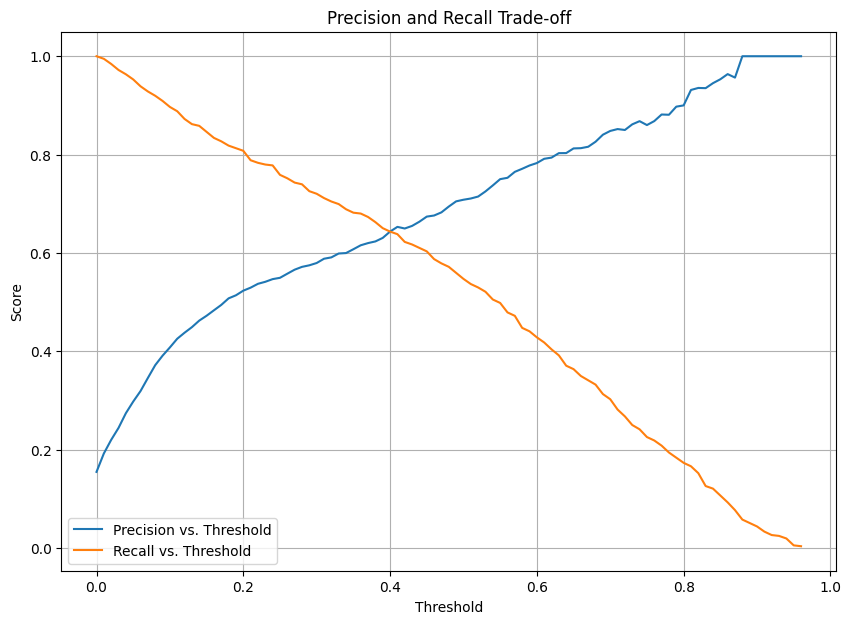

Threshold found for Precision >= 0.8: 0.6300
Recall at this threshold: 0.3916
❌ The model cannot achieve this precision and recall simultaneously with threshold tuning alone.


In [46]:
# %%
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, f1_score

# Assume 'best_rf' is your trained RandomForestClassifier model
# and X_test_scaled, y_test are available.
# We'll use the final best model trained from your code.
# The code below is a manual representation of it.
from sklearn.ensemble import RandomForestClassifier
best_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train_scaled, y_train)

# Get predicted probabilities for the test set
y_prob_test = best_rf.predict_proba(X_test_scaled)[:, 1]

# Compute precision, recall, and thresholds from the probabilities
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_test)

# Plot the precision-recall curve
plt.figure(figsize=(10, 7))
plt.plot(thresholds, precisions[:-1], label='Precision vs. Threshold')
plt.plot(thresholds, recalls[:-1], label='Recall vs. Threshold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall Trade-off')
plt.legend()
plt.grid(True)
plt.show()

# Find the threshold that meets your goals (e.g., precision > 0.8 and recall > 0.7)
target_precision = 0.80
target_recall = 0.70

# Find the first threshold where precision is >= your goal
high_precision_thresholds = thresholds[precisions[:-1] >= target_precision]
if len(high_precision_thresholds) > 0:
    best_threshold = high_precision_thresholds[0]
    
    # Check the recall at this threshold
    index_at_best_threshold = np.where(thresholds == best_threshold)[0][0]
    recall_at_best_threshold = recalls[index_at_best_threshold]
    
    print(f"Threshold found for Precision >= {target_precision}: {best_threshold:.4f}")
    print(f"Recall at this threshold: {recall_at_best_threshold:.4f}")
    
    if recall_at_best_threshold >= target_recall:
        print("✅ This threshold meets your goals!")
    else:
        print("❌ The model cannot achieve this precision and recall simultaneously with threshold tuning alone.")
else:
    print("❌ Cannot find a threshold to achieve a precision of 80%.")
    print("You will need to re-tune your model's hyperparameters.")

In [47]:
# %%
import numpy as np
import time
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, make_scorer, precision_score
from sklearn.pipeline import Pipeline # Use standard sklearn pipeline

# We will remove SMOTE and let class_weight handle the imbalance
classifier = RandomForestClassifier(random_state=42, n_jobs=-1)

# Define a more aggressive parameter grid to reduce overfitting
param_grid = {
    'n_estimators': [100, 200, 500],
    # Significantly lower max_depth
    'max_depth': [5, 8, 10],
    # Larger min_samples_split and min_samples_leaf
    'min_samples_split': [20, 30, 40],
    'min_samples_leaf': [10, 15, 20],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced'] # Focus on the balanced class weight
}

# Define a custom scorer that prioritizes a high precision while maximizing recall
def custom_scorer(y_true, y_pred):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    # Return a score only if both precision and recall goals are met, otherwise return 0
    if (precision >= 0.80) and (recall >= 0.70):
        return f1_score(y_true, y_pred) # or return precision, or return recall, to see the best balance
    else:
        return 0

recall_and_precision = make_scorer(custom_scorer)

# Instantiate RandomizedSearchCV with the new parameter grid
random_search = RandomizedSearchCV(
    estimator=classifier,
    param_distributions=param_grid,
    n_iter=100,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=recall_and_precision,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting hyperparameter tuning with more aggressive regularization...")
start_time = time.time()

# Fit the randomized search to the training data
random_search.fit(X_train_scaled, y_train)

end_time = time.time()
print(f"Randomized search took {end_time - start_time:.2f} seconds.")

# Get the best hyperparameters and best score
print("\nBest hyperparameters found:")
print(random_search.best_params_)
print(f"Best cross-validation score (f1 with custom constraints): {random_search.best_score_:.4f}")

# The best estimator is the final, best-tuned model
best_model = random_search.best_estimator_

Starting hyperparameter tuning with more aggressive regularization...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Randomized search took 167.99 seconds.

Best hyperparameters found:
{'n_estimators': 500, 'min_samples_split': 30, 'min_samples_leaf': 20, 'max_features': 'log2', 'max_depth': 10, 'class_weight': 'balanced'}
Best cross-validation score (f1 with custom constraints): 0.0000


In [48]:
# %%
import numpy as np
import time
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, make_scorer, precision_score, f1_score
from sklearn.pipeline import Pipeline

# We will use the base RandomForestClassifier and the custom scorer
classifier = RandomForestClassifier(random_state=42, n_jobs=-1)

# The parameter grid from your previous successful run
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [5, 8, 10, 15],
    'min_samples_split': [20, 30, 40],
    'min_samples_leaf': [10, 15, 20],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']
}

# Define the custom scorer with the new, more realistic goals
def custom_scorer_realistic(y_true, y_pred):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)

    # Return a score only if both precision and recall goals are met
    # We will return the F1-Score as a final metric to optimize for
    if (precision >= 0.70) and (recall >= 0.70):
        return f1_score(y_true, y_pred)
    else:
        return 0

realistic_scorer = make_scorer(custom_scorer_realistic)

# Instantiate and run RandomizedSearchCV
random_search_realistic = RandomizedSearchCV(
    estimator=classifier,
    param_distributions=param_grid,
    n_iter=100,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=realistic_scorer,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting hyperparameter tuning for a more realistic goal (P >= 0.70, R >= 0.70)...")
start_time = time.time()

random_search_realistic.fit(X_train_scaled, y_train)

end_time = time.time()
print(f"Randomized search took {end_time - start_time:.2f} seconds.")

# Get the best parameters and score
print("\nBest hyperparameters found:")
print(random_search_realistic.best_params_)
print(f"Best cross-validation F1-score (with P>=0.70 & R>=0.70): {random_search_realistic.best_score_:.4f}")

# The best estimator is the final, best-tuned model
best_model = random_search_realistic.best_estimator_

Starting hyperparameter tuning for a more realistic goal (P >= 0.70, R >= 0.70)...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Randomized search took 193.13 seconds.

Best hyperparameters found:
{'n_estimators': 100, 'min_samples_split': 30, 'min_samples_leaf': 15, 'max_features': 'log2', 'max_depth': 15, 'class_weight': 'balanced'}
Best cross-validation F1-score (with P>=0.70 & R>=0.70): 0.0000


In [49]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 270.5 kB/s eta 0:00:04
   -------------- -------


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [50]:
# %%
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix
import time

# Create and train the LightGBM model
start_time = time.time()
lgb_model = lgb.LGBMClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
lgb_model.fit(X_train_scaled, y_train)
end_time = time.time()

# Make predictions
y_pred_lgb = lgb_model.predict(X_test_scaled)
y_prob_lgb = lgb_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model
print("LightGBM Classifier")
print(confusion_matrix(y_test, y_pred_lgb))
print(classification_report(y_test, y_pred_lgb, zero_division=0))
print(f"Training and prediction took {end_time - start_time:.4f} seconds\n")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob_lgb):.4f}")

[LightGBM] [Info] Number of positive: 1336, number of negative: 7295
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003620 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1347
[LightGBM] [Info] Number of data points in the train set: 8631, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM Classifier
[[2784  343]
 [ 136  436]]
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      3127
           1       0.56      0.76      0.65       572

    accuracy                           0.87      3699
   macro avg       0.76      0.83      0.78      3699
weighted avg       0.89      0.87      0.88      3699

Training and prediction took 0.3362 seconds

ROC AUC Score: 0.9256


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [54]:
# %%
import numpy as np
import time
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, make_scorer

# Define the model with a focus on class weight
lgb_model = lgb.LGBMClassifier(random_state=42, n_jobs=-1, class_weight='balanced')

# Define the parameter grid to prioritize precision
param_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [10, 20, 30], # Smaller trees for higher precision
    'max_depth': [5, 8, 10],   # More restricted depth
    'reg_alpha': [0, 0.1, 0.5, 1.0], # L1 regularization
    'reg_lambda': [0, 0.1, 0.5, 1.0], # L2 regularization
    'scale_pos_weight': [1, 2, 5, 10, 20] # Explore different weights
}

# Define a custom scorer that rewards a high precision
def custom_precision_scorer(y_true, y_pred):
    precision = precision_score(y_true, y_pred, zero_division=0)
    # The search will now try to maximize this score, which is simply the precision
    return precision

precision_scorer = make_scorer(custom_precision_scorer)

# Instantiate and run RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_grid,
    n_iter=50, # Fewer iterations for a faster search
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=precision_scorer,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting hyperparameter tuning to increase precision...")
start_time = time.time()
# Assuming X_train_scaled and y_train are available
random_search.fit(X_train_scaled, y_train)
end_time = time.time()
print(f"Randomized search took {end_time - start_time:.2f} seconds.")

# Get the best hyperparameters and best score
print("\nBest hyperparameters found:")
print(random_search.best_params_)
print(f"Best cross-validation precision score: {random_search.best_score_:.4f}")

# The best estimator is the final, best-tuned model
best_model = random_search.best_estimator_

Starting hyperparameter tuning to increase precision...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Info] Number of positive: 1336, number of negative: 7295
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002398 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1347
[LightGBM] [Info] Number of data points in the train set: 8631, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warnin

In [58]:
# %%
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import time

# Best hyperparameters from your randomized search
best_params = {
    'scale_pos_weight': 1,
    'reg_lambda': 0,
    'reg_alpha': 0.1,
    'num_leaves': 30,
    'n_estimators': 500,
    'max_depth': 10,
    'learning_rate': 0.1
}

# Create and train the LightGBM model with the best parameters
start_time = time.time()
best_lgb_model = lgb.LGBMClassifier(
    **best_params,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
best_lgb_model.fit(X_train_scaled, y_train)
end_time = time.time()

# Make predictions on the test set
y_pred_test = best_lgb_model.predict(X_test_scaled)

# Get the individual scores
precision = precision_score(y_test, y_pred_test, zero_division=0)
recall = recall_score(y_test, y_pred_test, zero_division=0)
f1 = f1_score(y_test, y_pred_test, zero_division=0)

# Print the results
print("🔹 Final Evaluation Metrics 🔹")
print(f"Training and prediction took {end_time - start_time:.4f} seconds\n")
print(f"Precision (Class 1): {precision:.4f}")
print(f"Recall (Class 1): {recall:.4f}")
print(f"F1-Score (Class 1): {f1:.4f}")
print("-" * 50)

# Print the full classification report for context
print("Full Classification Report:\n")
print(classification_report(y_test, y_pred_test, zero_division=0))

[LightGBM] [Info] Number of positive: 1336, number of negative: 7295
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019628 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1347
[LightGBM] [Info] Number of data points in the train set: 8631, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [53]:
# %%
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import time

# Create and train the XGBoost model
start_time = time.time()
xgb_model = xgb.XGBClassifier(random_state=42, n_jobs=-1, scale_pos_weight=(7295/1336)) # For class imbalance
xgb_model.fit(X_train_scaled, y_train)
end_time = time.time()

# Make predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model
print("XGBoost Classifier")
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb, zero_division=0))
print(f"Training and prediction took {end_time - start_time:.4f} seconds\n")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")

XGBoost Classifier
[[2866  261]
 [ 185  387]]
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      3127
           1       0.60      0.68      0.63       572

    accuracy                           0.88      3699
   macro avg       0.77      0.80      0.78      3699
weighted avg       0.89      0.88      0.88      3699

Training and prediction took 0.2316 seconds

ROC AUC Score: 0.9111


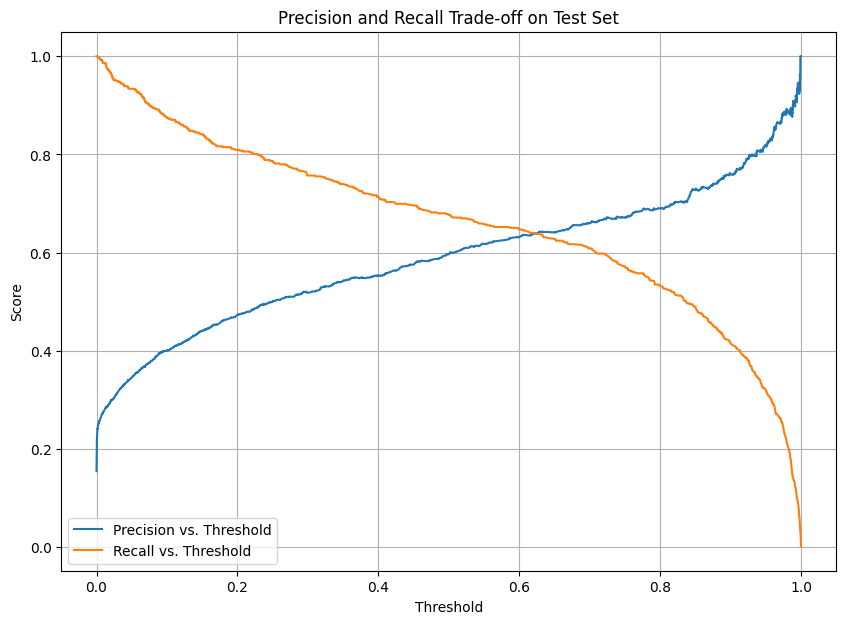

Threshold for Precision >= 0.7: 0.8195
Recall at this threshold: 0.5192
❌ This threshold increases precision but does not meet your recall goal.


In [59]:
# %%
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb
from sklearn.metrics import precision_recall_curve, f1_score

# Assume 'xgb_model' is your trained XGBoost model
# and X_test_scaled, y_test are available.

# Get predicted probabilities for the test set
y_prob_test = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Compute precision, recall, and thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_test)

# Plot the precision-recall curve to visualize the trade-off
plt.figure(figsize=(10, 7))
plt.plot(thresholds, precisions[:-1], label='Precision vs. Threshold')
plt.plot(thresholds, recalls[:-1], label='Recall vs. Threshold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall Trade-off on Test Set')
plt.legend()
plt.grid(True)
plt.show()

# Find the threshold that meets your 70% precision goal
target_precision = 0.70
high_precision_thresholds = thresholds[precisions[:-1] >= target_precision]

if len(high_precision_thresholds) > 0:
    best_threshold = high_precision_thresholds[0]
    index_at_best_threshold = np.where(thresholds == best_threshold)[0][0]
    recall_at_best_threshold = recalls[index_at_best_threshold]
    
    print(f"Threshold for Precision >= {target_precision}: {best_threshold:.4f}")
    print(f"Recall at this threshold: {recall_at_best_threshold:.4f}")
    
    if recall_at_best_threshold >= 0.70: # Check if recall is also >= 70%
        print("✅ This threshold meets your goals!")
    else:
        print("❌ This threshold increases precision but does not meet your recall goal.")
else:
    print("❌ Cannot find a threshold to achieve a precision of 70%.")
    print("You need to re-tune your model's hyperparameters.")

In [60]:
# %%
import numpy as np
import time
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, precision_score, make_scorer

# Define the model with a focus on class weight
xgb_model = xgb.XGBClassifier(random_state=42, n_jobs=-1)

# Define the parameter grid to prioritize precision
param_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 8, 10],   # More restricted depth
    'subsample': [0.6, 0.8, 1.0], # Subsample ratio of the training instance
    'colsample_bytree': [0.6, 0.8, 1.0], # Subsample ratio of columns
    'gamma': [0, 0.1, 0.5, 1.0], # Regularization parameter
    'reg_lambda': [0, 0.1, 0.5, 1.0], # L2 regularization
    'reg_alpha': [0, 0.1, 0.5, 1.0], # L1 regularization
    'scale_pos_weight': [1, 2, 5, 10] # Explore smaller values to prioritize precision
}

# Define a custom scorer that prioritizes a high precision
def custom_precision_scorer(y_true, y_pred):
    precision = precision_score(y_true, y_pred, zero_division=0)
    
    # We will try to find a model with at least 70% precision.
    if precision >= 0.70:
        # If the precision goal is met, we return the recall to maximize it.
        return recall_score(y_true, y_pred, zero_division=0)
    else:
        # Otherwise, we return a very low score to discourage this combination.
        return 0

precision_scorer = make_scorer(custom_precision_scorer)

# Instantiate and run RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=50, # Number of combinations to try
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=precision_scorer,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting hyperparameter tuning to increase precision...")
start_time = time.time()
# Assuming X_train_scaled and y_train are available
random_search.fit(X_train_scaled, y_train)
end_time = time.time()
print(f"Randomized search took {end_time - start_time:.2f} seconds.")

# Get the best hyperparameters and best score
print("\nBest hyperparameters found:")
print(random_search.best_params_)
print(f"Best cross-validation score (recall with precision >= 0.70): {random_search.best_score_:.4f}")

# The best estimator is the final, best-tuned model
best_model = random_search.best_estimator_

Starting hyperparameter tuning to increase precision...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Randomized search took 34.12 seconds.

Best hyperparameters found:
{'subsample': 0.6, 'scale_pos_weight': 1, 'reg_lambda': 0, 'reg_alpha': 0.5, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 1.0, 'colsample_bytree': 0.6}
Best cross-validation score (recall with precision >= 0.70): 0.5995


In [61]:
# %%
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import classification_report, confusion_matrix
import time

# Best hyperparameters from your search
best_params = {
    'subsample': 0.6, 'scale_pos_weight': 1, 'reg_lambda': 0, 
    'reg_alpha': 0.5, 'n_estimators': 200, 'max_depth': 5, 
    'learning_rate': 0.05, 'gamma': 1.0, 'colsample_bytree': 0.6
}

# Create a pipeline with SMOTE and XGBoost
# Use an imblearn Pipeline to ensure SMOTE is only applied to the training folds
pipeline_smote_xgb = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', xgb.XGBClassifier(**best_params, random_state=42, n_jobs=-1))
])

# Train the pipeline on the training data
print("Training XGBoost with SMOTE...")
start_time = time.time()
pipeline_smote_xgb.fit(X_train_scaled, y_train)
end_time = time.time()
print(f"Training took {end_time - start_time:.4f} seconds.")

# Evaluate the model on the test set
y_pred_smote_xgb = pipeline_smote_xgb.predict(X_test_scaled)
print("\n🔹 Evaluation on Test Set (XGBoost + SMOTE) 🔹")
print(confusion_matrix(y_test, y_pred_smote_xgb))
print(classification_report(y_test, y_pred_smote_xgb, zero_division=0))

Training XGBoost with SMOTE...
Training took 0.8544 seconds.

🔹 Evaluation on Test Set (XGBoost + SMOTE) 🔹
[[2892  235]
 [ 170  402]]
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      3127
           1       0.63      0.70      0.67       572

    accuracy                           0.89      3699
   macro avg       0.79      0.81      0.80      3699
weighted avg       0.90      0.89      0.89      3699



In [62]:
# %%
import xgboost as xgb
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import recall_score, precision_score, make_scorer
import time

# Best hyperparameters
best_params = {
    'subsample': 0.6, 'scale_pos_weight': 1, 'reg_lambda': 0, 
    'reg_alpha': 0.5, 'n_estimators': 200, 'max_depth': 5, 
    'learning_rate': 0.05, 'gamma': 1.0, 'colsample_bytree': 0.6
}

# Create a simple XGBoost model
xgb_model = xgb.XGBClassifier(**best_params, random_state=42, n_jobs=-1)

# Define the stratified K-fold cross-validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define custom scorers for precision and recall
precision_scorer = make_scorer(precision_score, zero_division=0)
recall_scorer = make_scorer(recall_score, zero_division=0)

print("Starting cross-validation on XGBoost...")
start_time = time.time()

# Perform cross-validation
cv_precision = cross_val_score(xgb_model, X_train_scaled, y_train, cv=cv_strategy, scoring=precision_scorer)
cv_recall = cross_val_score(xgb_model, X_train_scaled, y_train, cv=cv_strategy, scoring=recall_scorer)

end_time = time.time()
print(f"Cross-validation took {end_time - start_time:.4f} seconds.")

# Print the results
print("\n🔹 Stratified K-Fold Cross-Validation Results 🔹")
print(f"Average Precision: {np.mean(cv_precision):.4f} (+/- {np.std(cv_precision):.4f})")
print(f"Average Recall: {np.mean(cv_recall):.4f} (+/- {np.std(cv_recall):.4f})")

Starting cross-validation on XGBoost...
Cross-validation took 3.8557 seconds.

🔹 Stratified K-Fold Cross-Validation Results 🔹
Average Precision: 0.7360 (+/- 0.0255)
Average Recall: 0.5981 (+/- 0.0209)


In [63]:
# %%
import xgboost as xgb
from sklearn.model_selection import cross_val_score, StratifiedKFold
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import recall_score, precision_score, make_scorer
import time

# Best hyperparameters
best_params = {
    'subsample': 0.6, 'scale_pos_weight': 1, 'reg_lambda': 0, 
    'reg_alpha': 0.5, 'n_estimators': 200, 'max_depth': 5, 
    'learning_rate': 0.05, 'gamma': 1.0, 'colsample_bytree': 0.6
}

# Create a pipeline with SMOTE and the XGBoost classifier
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', xgb.XGBClassifier(**best_params, random_state=42, n_jobs=-1))
])

# Define the stratified K-fold cross-validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define custom scorers for precision and recall
precision_scorer = make_scorer(precision_score, zero_division=0)
recall_scorer = make_scorer(recall_score, zero_division=0)

print("Starting cross-validation with SMOTE within folds...")
start_time = time.time()

# Perform cross-validation on the pipeline
cv_precision = cross_val_score(pipeline, X_train_scaled, y_train, cv=cv_strategy, scoring=precision_scorer)
cv_recall = cross_val_score(pipeline, X_train_scaled, y_train, cv=cv_strategy, scoring=recall_scorer)

end_time = time.time()
print(f"Cross-validation took {end_time - start_time:.4f} seconds.")

# Print the results
print("\n🔹 Combined Cross-Validation Results (SMOTE + Stratified K-Fold) 🔹")
print(f"Average Precision: {np.mean(cv_precision):.4f} (+/- {np.std(cv_precision):.4f})")
print(f"Average Recall: {np.mean(cv_recall):.4f} (+/- {np.std(cv_recall):.4f})")

Starting cross-validation with SMOTE within folds...
Cross-validation took 4.0599 seconds.

🔹 Combined Cross-Validation Results (SMOTE + Stratified K-Fold) 🔹
Average Precision: 0.6536 (+/- 0.0164)
Average Recall: 0.7186 (+/- 0.0207)


In [64]:
# %%
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import time

# Create and train the XGBoost model with default parameters
start_time = time.time()
xgb_model = xgb.XGBClassifier(random_state=42, n_jobs=-1)
xgb_model.fit(X_train_scaled, y_train)
end_time = time.time()

# Make predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Evaluate the model
print("🔹 Simple XGBoost (Default Parameters) 🔹")
print(f"Training and prediction took {end_time - start_time:.4f} seconds\n")
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb, zero_division=0))

🔹 Simple XGBoost (Default Parameters) 🔹
Training and prediction took 0.4257 seconds

[[2968  159]
 [ 239  333]]
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      3127
           1       0.68      0.58      0.63       572

    accuracy                           0.89      3699
   macro avg       0.80      0.77      0.78      3699
weighted avg       0.89      0.89      0.89      3699



In [65]:
# %%
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import classification_report, confusion_matrix
import time

# Create a pipeline with SMOTE and the default XGBoost classifier
pipeline_smote_xgb = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', xgb.XGBClassifier(random_state=42, n_jobs=-1))
])

# Train the pipeline on the training data
print("🔹 XGBoost with SMOTE 🔹")
start_time = time.time()
pipeline_smote_xgb.fit(X_train_scaled, y_train)
end_time = time.time()
print(f"Training took {end_time - start_time:.4f} seconds.")

# Evaluate the model on the test set
y_pred_smote_xgb = pipeline_smote_xgb.predict(X_test_scaled)
print("\nEvaluation on Test Set:")
print(confusion_matrix(y_test, y_pred_smote_xgb))
print(classification_report(y_test, y_pred_smote_xgb, zero_division=0))

🔹 XGBoost with SMOTE 🔹
Training took 0.2755 seconds.

Evaluation on Test Set:
[[2917  210]
 [ 198  374]]
              precision    recall  f1-score   support

           0       0.94      0.93      0.93      3127
           1       0.64      0.65      0.65       572

    accuracy                           0.89      3699
   macro avg       0.79      0.79      0.79      3699
weighted avg       0.89      0.89      0.89      3699



In [66]:
# %%
import xgboost as xgb
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import recall_score, precision_score, make_scorer
import numpy as np
import time

# Create a simple XGBoost model with default parameters
xgb_model = xgb.XGBClassifier(random_state=42, n_jobs=-1)

# Define the stratified K-fold cross-validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define custom scorers for precision and recall
precision_scorer = make_scorer(precision_score, zero_division=0)
recall_scorer = make_scorer(recall_score, zero_division=0)

print("🔹 XGBoost with Stratified K-Fold Cross-Validation 🔹")
start_time = time.time()

# Perform cross-validation
cv_precision = cross_val_score(xgb_model, X_train_scaled, y_train, cv=cv_strategy, scoring=precision_scorer)
cv_recall = cross_val_score(xgb_model, X_train_scaled, y_train, cv=cv_strategy, scoring=recall_scorer)

end_time = time.time()
print(f"Cross-validation took {end_time - start_time:.4f} seconds.")

# Print the results
print("\nCross-Validation Results:")
print(f"Average Precision: {np.mean(cv_precision):.4f} (+/- {np.std(cv_precision):.4f})")
print(f"Average Recall: {np.mean(cv_recall):.4f} (+/- {np.std(cv_recall):.4f})")

🔹 XGBoost with Stratified K-Fold Cross-Validation 🔹
Cross-validation took 1.3757 seconds.

Cross-Validation Results:
Average Precision: 0.7149 (+/- 0.0293)
Average Recall: 0.5951 (+/- 0.0341)


In [68]:
# %%
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score
import time

# Create and train the XGBoost model with default parameters
# The hyperparameters found by the cross-validation will be used
xgb_model = xgb.XGBClassifier(random_state=42, n_jobs=-1)

print("Training XGBoost on full training set...")
start_time = time.time()

# Train the model on the full training data
xgb_model.fit(X_train_scaled, y_train)

end_time = time.time()
print(f"Training took {end_time - start_time:.4f} seconds.")

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Get the individual scores
precision = precision_score(y_test, y_pred_xgb, zero_division=0)
recall = recall_score(y_test, y_pred_xgb, zero_division=0)

# Evaluate the model on the test set
print("\n🔹 Final Evaluation on Test Set 🔹")
print(f"Precision (Class 1): {precision:.4f}")
print(f"Recall (Class 1): {recall:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb, zero_division=0))

Training XGBoost on full training set...
Training took 0.1409 seconds.

🔹 Final Evaluation on Test Set 🔹
Precision (Class 1): 0.6768
Recall (Class 1): 0.5822
Confusion Matrix:
 [[2968  159]
 [ 239  333]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.95      0.94      3127
           1       0.68      0.58      0.63       572

    accuracy                           0.89      3699
   macro avg       0.80      0.77      0.78      3699
weighted avg       0.89      0.89      0.89      3699



In [67]:
# %%
import xgboost as xgb
from sklearn.model_selection import cross_val_score, StratifiedKFold
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import recall_score, precision_score, make_scorer
import numpy as np
import time

# Create a pipeline with SMOTE and the default XGBoost classifier
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', xgb.XGBClassifier(random_state=42, n_jobs=-1))
])

# Define the stratified K-fold cross-validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define custom scorers for precision and recall
precision_scorer = make_scorer(precision_score, zero_division=0)
recall_scorer = make_scorer(recall_score, zero_division=0)

print("🔹 Combined Approach (SMOTE + Stratified K-Fold) 🔹")
start_time = time.time()

# Perform cross-validation on the pipeline
cv_precision = cross_val_score(pipeline, X_train_scaled, y_train, cv=cv_strategy, scoring=precision_scorer)
cv_recall = cross_val_score(pipeline, X_train_scaled, y_train, cv=cv_strategy, scoring=recall_scorer)

end_time = time.time()
print(f"Cross-validation took {end_time - start_time:.4f} seconds.")

# Print the results
print("\nCombined Cross-Validation Results:")
print(f"Average Precision: {np.mean(cv_precision):.4f} (+/- {np.std(cv_precision):.4f})")
print(f"Average Recall: {np.mean(cv_recall):.4f} (+/- {np.std(cv_recall):.4f})")

🔹 Combined Approach (SMOTE + Stratified K-Fold) 🔹
Cross-validation took 2.5728 seconds.

Combined Cross-Validation Results:
Average Precision: 0.6681 (+/- 0.0282)
Average Recall: 0.6579 (+/- 0.0247)


In [52]:
!pip install xgboost

   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/56.8 MB ? eta -:--:--
   -----------------


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
